In [36]:
# Импорты

import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.linear_model import LinearRegression

# 1. Загрузка данных

df = pd.read_csv("data.csv", delimiter=';')
df = df[:-8]

df['date'] = pd.to_datetime(df['date1'].astype(str)+" "+df['date2'].astype(str))

df.set_index('date', inplace=True)
df['x1'] = df['x1'].apply(lambda x: x.replace(',','.')).astype(float)




In [ ]:
# Лабораторная работа №3
# 2. Декомпозиция

result = seasonal_decompose(df['x1'], model='additive', period=12)

trend = result.trend
seasonal = result.seasonal
residual = result.resid

In [ ]:
# 3. Прогноз тренда (линейная модель)


trend_clean = trend.dropna()


X = np.arange(len(trend_clean)).reshape(-1, 1)
y = trend_clean.values

model = LinearRegression()
model.fit(X, y)


forecast_steps = 8
X_future = np.arange(len(trend_clean), len(trend_clean) + forecast_steps).reshape(-1, 1)
trend_forecast = model.predict(X_future)

In [ ]:
# 4. Прогноз сезонности

seasonal_cycle = seasonal[-12:]

seasonal_forecast = np.tile(seasonal_cycle, int(np.ceil(forecast_steps / 12)))[:forecast_steps]


In [ ]:
# 5. Итоговый прогноз

forecast = trend_forecast + seasonal_forecast


last_date = df.index[-1]
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=forecast_steps, freq='M')

forecast_series = pd.Series(forecast, index=future_dates)

/tmp/ipykernel_7063/4259540686.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=forecast_steps, freq='M')


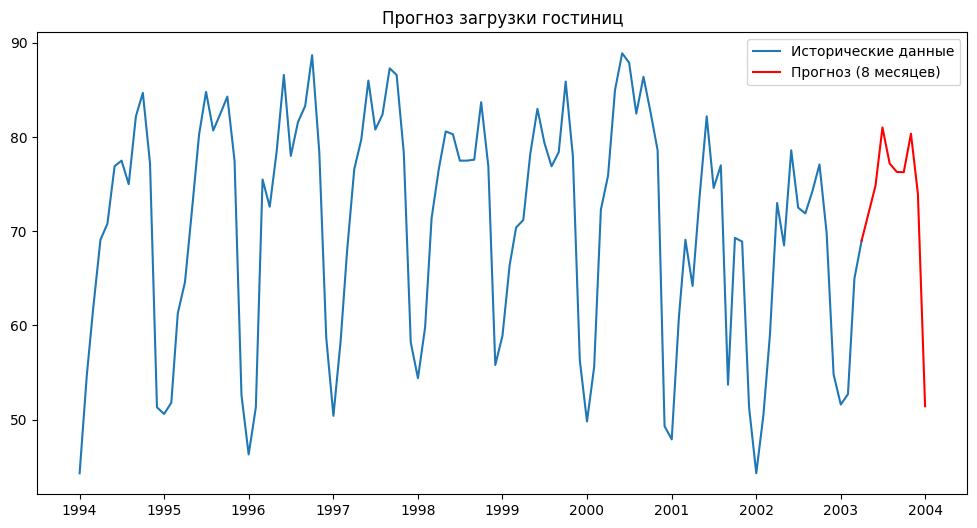

In [ ]:
# 6. Визуализация результата

plt.figure(figsize=(12, 6))
plt.plot(df['x1'], label='Исторические данные')
plt.plot(pd.concat([df['x1'][-1:],forecast_series]), label='Прогноз (8 месяцев)', color='red')
plt.legend()
plt.title('Прогноз загрузки гостиниц')
plt.show()

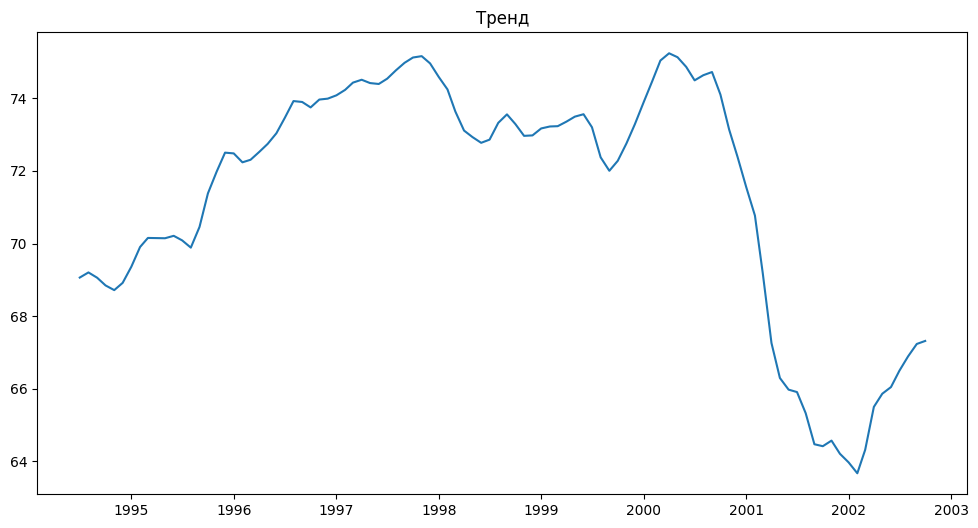

In [ ]:
# 6. Визуализация тренда

plt.figure(figsize=(12, 6))
plt.plot(trend_clean)


plt.title('Тренд')
plt.show()

In [ ]:
# 7. Вывод результата

print("Прогноз на 8 месяцев:")
print(forecast_series)

Прогноз на 8 месяцев:
2003-05-31    74.846070
2003-06-30    81.023053
2003-07-31    77.198764
2003-08-31    76.297564
2003-09-30    76.271365
2003-10-31    80.358592
2003-11-30    73.994950
2003-12-31    51.417246
Freq: ME, dtype: float64


In [37]:
# Лабораторная работа №4
# 2. Разделение train / test

test_size = 12
series = df['x1']
train = series[:-test_size]
test = series[-test_size:]

In [ ]:
# 3. Обучение модели

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error

model = ExponentialSmoothing(
    train,
    trend='add',
    seasonal='add',
    seasonal_periods=12
)

fitted_model = model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [ ]:
# 4. Прогноз на test и оценка качества

test_forecast = fitted_model.forecast(test_size)

mae = mean_absolute_error(test, test_forecast)
rmse = np.sqrt(mean_squared_error(test, test_forecast))
mape = np.mean(np.abs((test - test_forecast) / test)) * 100

print("=== Оценка модели на тесте ===")
print(f"MAE  = {mae:.2f}")
print(f"RMSE = {rmse:.2f}")
print(f"MAPE = {mape:.2f}%")


=== Оценка модели на тесте ===
MAE  = 2.46
RMSE = 3.05
MAPE = 3.89%


In [ ]:
# 5. Финальная модель (на всех данных)

# Видим ярко выраженную аддитивную сезонность
final_model = ExponentialSmoothing(
    series,
    trend='add',
    seasonal='add',
    seasonal_periods=12
).fit()

# Прогноз на 8 месяцев вперед
forecast_steps = 8
future_forecast = final_model.forecast(forecast_steps)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


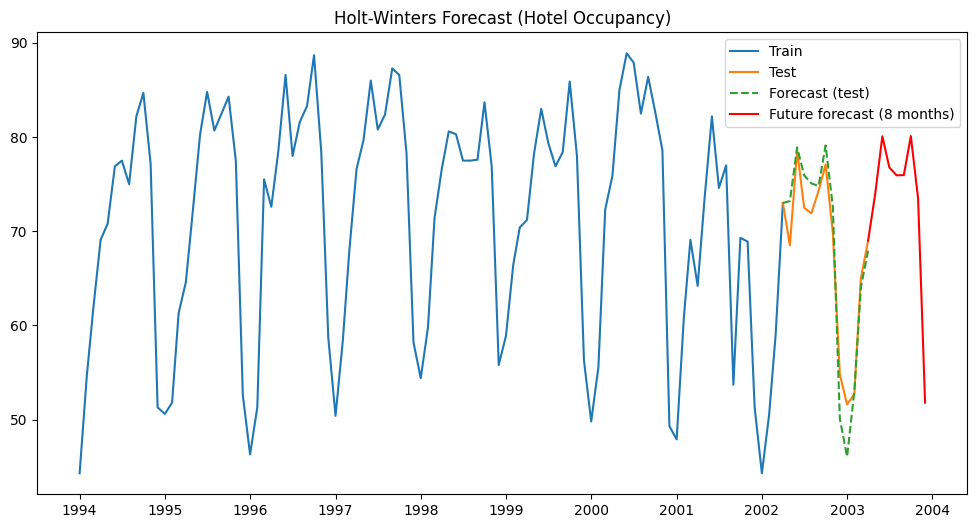

In [ ]:
# 6. Визуализация

plt.figure(figsize=(12, 6))

plt.plot(train, label='Train')
plt.plot(pd.concat([train[-1:],test]), label='Test')
plt.plot(pd.concat([train[-1:],test_forecast]), label='Forecast (test)', linestyle='--')

plt.plot(pd.concat([series[-1:],future_forecast]), label='Future forecast (8 months)', color='red')

plt.legend()
plt.title('Holt-Winters Forecast (Hotel Occupancy)')
plt.show()

In [ ]:
# 7. Вывод прогноза

print("\n=== Прогноз на 8 месяцев вперед ===")
print(future_forecast)


=== Прогноз на 8 месяцев вперед ===
2003-05-01    73.897242
2003-06-01    80.086176
2003-07-01    76.775077
2003-08-01    75.941776
2003-09-01    75.963654
2003-10-01    80.108165
2003-11-01    73.508085
2003-12-01    51.807992
Freq: MS, dtype: float64


In [4]:
# Лабораторная работа №5
# 2. Разделение train / test

test_size = 12
series = df['x1']
train = series[:-test_size]
test = series[-test_size:]

In [10]:
# 2. Подбор параметров ARIMA
# Подберем d с помощью ADF

from statsmodels.tsa.stattools import adfuller

result = adfuller(series)

print("ADF statistic:", result[0])
print("p-value:", result[1])


ADF statistic: -1.2593213528147214
p-value: 0.6475714100395678


In [25]:
# Вывод: ряд нестационарен, нужно дифференциировать

diff1 = series.diff().dropna()
result = adfuller(diff1)

print("ADF statistic:", result[0])
print("p-value:", result[1])


# p-value < 0.05 => d = 1

ADF statistic: -5.664861871011559
p-value: 9.201174410038701e-07


In [32]:
# Подберем D с помощью ADF

seasonal_diff = series.diff(12).dropna()
result = adfuller(seasonal_diff)

print("ADF statistic:", result[0])
print("p-value:", result[1])

# p-value < 0.05 => D = 1

ADF statistic: -4.073427900432466
p-value: 0.0010712479889859105


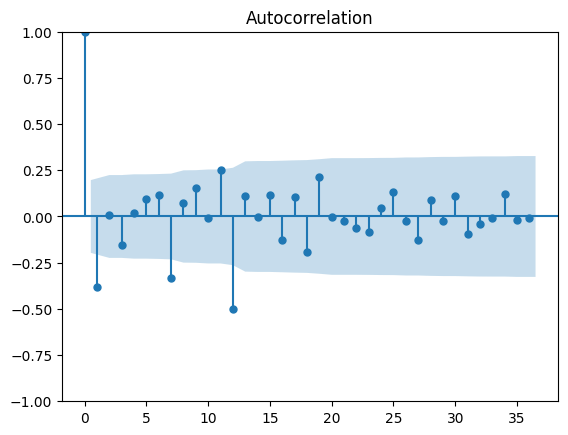

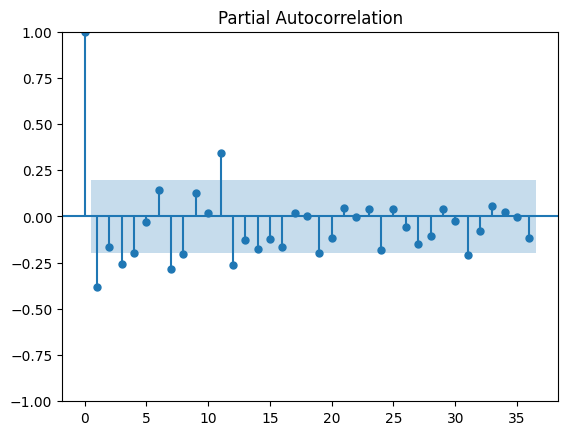

In [34]:
# Подбираем p/q с помощью PACF/ACF

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

stationary = series.diff().diff(12).dropna()
plot_acf(stationary, lags=36)
plt.show()

plot_pacf(stationary, lags=36)
plt.show()

По скачкам ACF и PACF не очевидно какие параметры брать

In [38]:
# Подберем перебором небольших значений и выберем по лучшему AIC

import itertools
from statsmodels.tsa.statespace.sarimax import SARIMAX

p = q = range(0, 3)
d = [1]
P = Q = range(0, 2)
D = [1]

best_aic = np.inf
best_params = None

for params in itertools.product(p, d, q):
    for seasonal in itertools.product(P, D, Q):

        try:
            model = SARIMAX(
                train,
                order=params,
                seasonal_order=(
                    seasonal[0],
                    seasonal[1],
                    seasonal[2],
                    12
                ),
                enforce_stationarity=False,
                enforce_invertibility=False
            )

            result = model.fit(disp=False)

            if result.aic < best_aic:
                best_aic = result.aic
                best_params = (params, seasonal)

        except:
            continue

print("Best model:", best_params)
print("Best AIC:", best_aic)

Best model: ((0, 1, 2), (1, 1, 1))
Best AIC: 445.5607834158965


In [43]:
# 3. Обучение SARIMA

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

model = SARIMAX(
    train,
    order=(0, 1, 2),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

fitted_model = model.fit(disp=False)

''' Для прогнозирования использована сезонная модель ARIMA (SARIMA), поскольку
временной ряд коэффициента загрузки гостиниц обладает выраженным трендом (d = 1) и годовой сезонностью (D = 1). '''

' Для прогнозирования использована сезонная модель ARIMA (SARIMA), поскольку \nвременной ряд коэффициента загрузки гостиниц обладает выраженным трендом (d = 1) и годовой сезонностью (D = 1). '

In [44]:
# 4. Прогноз на test и метрики

test_forecast = fitted_model.forecast(steps=test_size)

mae = mean_absolute_error(test, test_forecast)
rmse = np.sqrt(mean_squared_error(test, test_forecast))
mape = np.mean(np.abs((test - test_forecast) / test)) * 100

print(f"MAE  = {mae:.3f}")
print(f"RMSE = {rmse:.3f}")
print(f"MAPE = {mape:.2f}%")

MAE  = 3.437
RMSE = 4.762
MAPE = 5.58%


In [45]:
# 5. Финальная модель обученная на всех данных

final_model = SARIMAX(
    series,
    order=(0,1,2),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

final_fit = final_model.fit(disp=False)

In [46]:
# 6. Прогноз
forecast_steps = 8
future_forecast = final_fit.forecast(steps=forecast_steps)

print("\n=== Прогноз на 8 месяцев ===")
print(future_forecast)


=== Прогноз на 8 месяцев ===
2003-05-01    74.502651
2003-06-01    80.209876
2003-07-01    75.819103
2003-08-01    75.143701
2003-09-01    69.401819
2003-10-01    75.768220
2003-11-01    71.134015
2003-12-01    49.640859
Freq: MS, Name: predicted_mean, dtype: float64


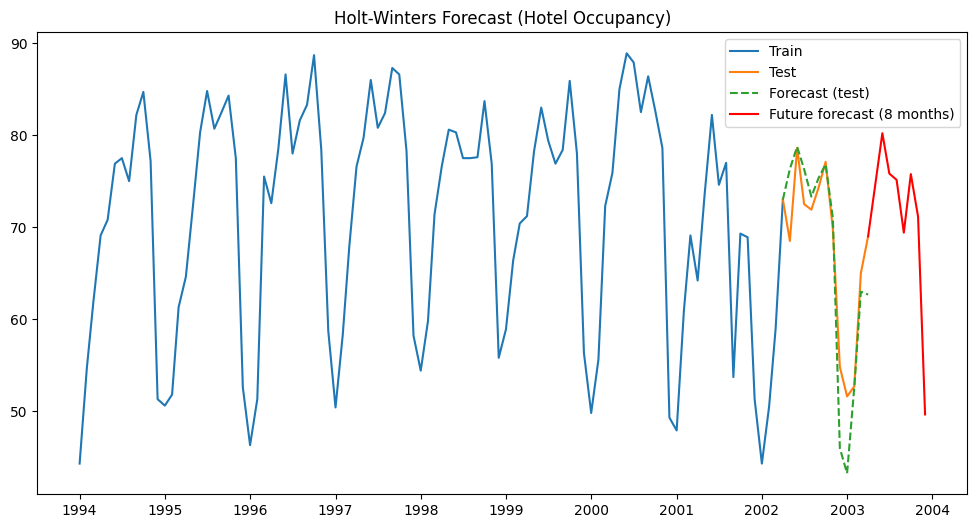

In [47]:
# 7. Визуализация результатов

plt.figure(figsize=(12, 6))

plt.plot(train, label='Train')
plt.plot(pd.concat([train[-1:],test]), label='Test')
plt.plot(pd.concat([train[-1:],test_forecast]), label='Forecast (test)', linestyle='--')

plt.plot(pd.concat([series[-1:],future_forecast]), label='Future forecast (8 months)', color='red')

plt.legend()
plt.title('Holt-Winters Forecast (Hotel Occupancy)')
plt.show()

In [48]:
# Базовая модель

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

model = SARIMAX(
    train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

fitted_model = model.fit(disp=False)

test_forecast = fitted_model.forecast(steps=test_size)

mae = mean_absolute_error(test, test_forecast)
rmse = np.sqrt(mean_squared_error(test, test_forecast))
mape = np.mean(np.abs((test - test_forecast) / test)) * 100

print(f"MAE  = {mae:.3f}")
print(f"RMSE = {rmse:.3f}")
print(f"MAPE = {mape:.2f}%")

MAE  = 3.647
RMSE = 4.809
MAPE = 5.84%
